shape: (1, 11)
┌────────────┬────────────┬──────────┬─────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ start      ┆ end        ┆ SR       ┆ Sortino ┆ … ┆ DailyTrad ┆ ReturnOve ┆ ReturnOve ┆ MaxPositi │
│ ---        ┆ ---        ┆ ---      ┆ ---     ┆   ┆ ingValue  ┆ rMDD      ┆ rTrade    ┆ onValue   │
│ datetime[μ ┆ datetime[μ ┆ f64      ┆ f64     ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---       │
│ s]         ┆ s]         ┆          ┆         ┆   ┆ f64       ┆ f64       ┆ f64       ┆ f64       │
╞════════════╪════════════╪══════════╪═════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ 2025-02-01 ┆ 2025-02-01 ┆ 1.772023 ┆ 2.49851 ┆ … ┆ 9.0918e8  ┆ 0.113446  ┆ 0.000032  ┆ 2.9531e7  │
│ 00:00:00   ┆ 23:59:50   ┆          ┆         ┆   ┆           ┆           ┆           ┆           │
└────────────┴────────────┴──────────┴─────────┴───┴───────────┴───────────┴───────────┴───────────┘


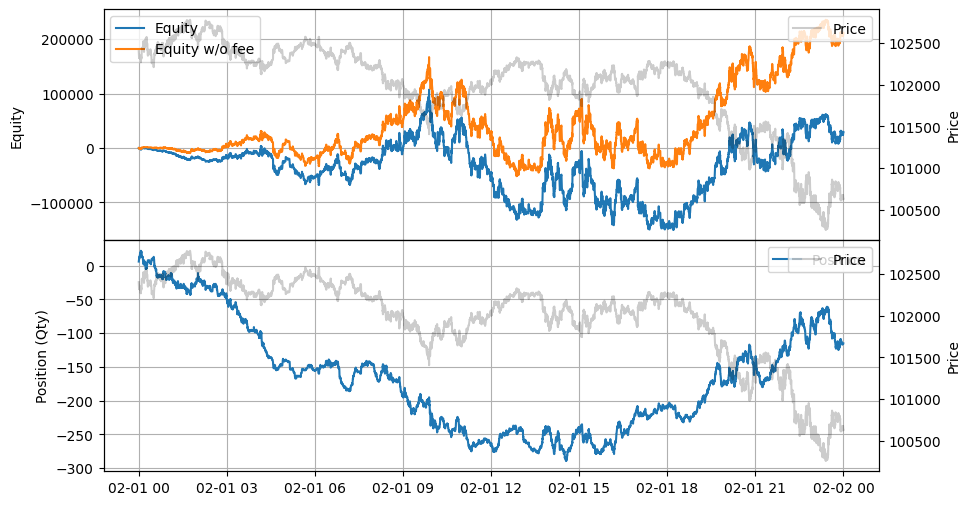

In [2]:
from hftbacktest import BacktestAsset, HashMapMarketDepthBacktest
from hftbacktest import GTC, GTX
from hftbacktest import LIMIT, GTC, NONE, NEW, FILLED, CANCELED, EXPIRED
import numpy as np
from numba import njit
from hftbacktest import MARKET
from hftbacktest import Recorder
from hftbacktest.stats import LinearAssetRecord


asset = (
    BacktestAsset()
        # Sets the data to feed for this asset.
        #
        # Due to the vast size of tick-by-tick market depth and trade data,
        # loading the entire dataset into memory can be challenging,
        # particularly when backtesting across multiple days.
        # HftBacktest offers lazy loading support and is compatible with npy and preferably npz.
        #
        # For details on the normalized feed data, refer to the following documents.
        # * https://hftbacktest.readthedocs.io/en/latest/data.html
        # * https://hftbacktest.readthedocs.io/en/latest/tutorials/Data%20Preparation.html
        .data(['../data/convert/btcusdt_20250201.npz'])
        # Sets the initial snapshot (optional).
        # .initial_snapshot('data/btcusdt_20251116_eod.npz')
        # Asset type:
        # * Linear
        # * Inverse.
        # 1.0 represents the contract size, which is the value of the asset per quoted price.
        .linear_asset(1.0)
        # HftBacktest provides two built-in latency models.
        # * constant_latency
        # * intp_order_latency
        # To implement your own latency model, please use Rust.
        #
        # Time unit is the same as data's timestamp's unit. Timestamp of the sample data is in nanoseconds.
        # Sets the order entry latency and response latency to 10ms.
        .constant_latency(10_000_000, 10_000_000)
        # HftBacktest provides several types of built-in queue position models.
        # Please find the details in the documents below.
        # https://hftbacktest.readthedocs.io/en/latest/tutorials/Probability%20Queue%20Models.html
        #
        # To implement your own queue position model, please use Rust.
        .risk_adverse_queue_model()
        # HftBacktest provides two built-in exchange models.
        # * no_partial_fill_exchange
        # * partial_fill_exchange
        # To implement your own exchange model, please use Rust.
        .no_partial_fill_exchange()
        # HftBacktest provides several built-in fee models.
        # * trading_value_fee_model
        # * trading_qty_fee_model
        # * flat_per_trade_fee_model
        #
        # 0.02% maker fee and 0.07% taker fee. If the fee is negative, it represents a rebate.
        # For example, -0.00005 represents a 0.005% rebate for the maker order.
        .trading_value_fee_model(0.0002, 0.0007)
        # Tick size of this asset: minimum price increasement
        .tick_size(0.1)
        # Lot size of this asset: minimum trading unit.
        .lot_size(0.001)
        # Sets the capacity of the vector that stores trades occurring in the market.
        # If you set the size, you need call `clear_last_trades` to clear the vector.
        # A value of 0 indicates that no market trades are stored. (Default)
        .last_trades_capacity(0)
    )



@njit
def print_orders_exec_price(hbt):
    orders = hbt.orders(0)
    order_values = orders.values()
    while order_values.has_next():
        order = order_values.get()

        order_status = ''
        if order.status == NONE:
            order_status = 'NONE'
        elif order.status == NEW:
            order_status = 'NEW'
        elif order.status == FILLED:
            order_status = 'FILLED'
        elif order.status == CANCELED:
            order_status = 'CANCELED'
        elif order.status == EXPIRED:
            order_status = 'EXPIRED'

        order_req = ''
        if order.req == NONE:
            order_req = 'NONE'
        elif order.req == NEW:
            order_req = 'NEW'
        elif order.req == CANCELED:
            order_req = 'CANCEL'

        print(
            'current_timestamp:', hbt.current_timestamp,
             ', order_id:', order.order_id,
             ', order_price:', np.round(order.price, 1),
             ', order_qty:', order.qty,
             ', order_status:', order_status,
             ', exec_price:', np.round(order.exec_price, 1)
        )

@njit
def print_orders(hbt):
    # You can access open orders and also closed orders via hbt.orders.
    # Gets the OrderDict for the first asset.
    orders = hbt.orders(0)

    # hbt.orders is a dictionary, but be aware that it does not support all dict methods, and its keys are order_id (int).
    order_values = orders.values()
    while order_values.has_next():
        order = order_values.get()

        order_status = ''
        if order.status == NONE:
            order_status = 'NONE' # Exchange hasn't received an order yet.
        elif order.status == NEW:
            order_status = 'NEW'
        elif order.status == FILLED:
            order_status = 'FILLED'
        elif order.status == CANCELED:
            order_status = 'CANCELED'
        elif order.status == EXPIRED:
            order_status = 'EXPIRED'

        order_req = ''
        if order.req == NONE:
            order_req = 'NONE'
        elif order.req == NEW:
            order_req = 'NEW'
        elif order.req == CANCELED:
            order_req = 'CANCEL'

        print(
            'current_timestamp:', hbt.current_timestamp,
             ', order_id:', order.order_id,
             ', order_price:', np.round(order.price, 1),
             ', order_qty:', order.qty,
             ', order_status:', order_status,
             ', order_req:', order_req
        )

@njit
def market_order(hbt):
    is_order_submitted = False
    while hbt.elapse(60 * 1e9) == 0:
        print_orders(hbt)

        hbt.clear_inactive_orders(0)

        state_values = hbt.state_values(0)

        print(
            'current_timestamp:', hbt.current_timestamp,
             ', position:', hbt.position(0),
             ', balance:', state_values.balance,
             ', fee:', state_values.fee
        )

        if not is_order_submitted:
            depth = hbt.depth(0)

            order_id = 1
            # Sets an arbitrary price, which does not affect MARKET orders.
            order_price = depth.best_bid
            order_qty = 1
            time_in_force = GTC
            order_type = MARKET
            hbt.submit_sell_order(0, order_id, order_price, order_qty, time_in_force, order_type, False)
            hbt.wait_order_response(0, order_id, 1e9)
            # You can see the order immediately filled.
            # Also you can see the order executed at the best bid which is different from what it was submitted at.
            print('best_bid:', depth.best_bid)
            print_orders_exec_price(hbt)
            is_order_submitted = True
    return True

@njit
def submit_order_stats(hbt, recorder):
    buy_order_id = 1
    sell_order_id = 2
    half_spread = 5 * hbt.depth(0).tick_size

    while hbt.elapse(1 * 1e9) == 0:
        hbt.clear_inactive_orders(0)

        depth = hbt.depth(0)

        mid_price = (depth.best_bid + depth.best_ask) / 2.0

        if buy_order_id not in hbt.orders(0):
            order_price = round((mid_price - half_spread) / depth.tick_size) * depth.tick_size
            order_qty = 1
            time_in_force = GTX
            order_type = LIMIT
            hbt.submit_buy_order(0, buy_order_id, order_price, order_qty, time_in_force, order_type, False)
        else:
            hbt.cancel(0, buy_order_id, False)

        if sell_order_id not in hbt.orders(0):
            order_price = round((mid_price + half_spread) / depth.tick_size) * depth.tick_size
            order_qty = 1
            time_in_force = GTX
            order_type = LIMIT
            hbt.submit_sell_order(0, sell_order_id, order_price, order_qty, time_in_force, order_type, False)
        else:
            hbt.cancel(0, sell_order_id, False)

        recorder.record(hbt)
    return True

hbt = HashMapMarketDepthBacktest([asset])

recorder = Recorder(
    # The number of assets
    hbt.num_assets,
    # The buffer size for records
    1000000
)

submit_order_stats(hbt, recorder.recorder)

_ = hbt.close()


# Constructs the LinearAssetRecord from the recorded data.
record = LinearAssetRecord(recorder.get(0))

# Generates the statistics.
# You can generate monthly and daily statistics, as well as custom metrics.
stats = record.stats()

# Prints the summary.
print(stats.summary())

stats.plot_matplotlib()

